## 1. Problema

El objetivo de este proyecto es desarrollar un modelo de lenguaje basado en redes neuronales recurrentes (LSTM) capaz de generar texto en español con estilo literario similar al de *Don Quijote de la Mancha*.

Este problema corresponde a la tarea de Language Modeling, donde el modelo aprende a predecir la siguiente palabra dada una secuencia previa.

La importancia del problema radica en:
- Comprender cómo las redes neuronales modelan secuencias de texto
- Aplicar NLP en generación de texto
- Explorar limitaciones de modelos secuenciales clásicos

In [1]:
import sys

print(sys.executable)


/Users/macbookair/Documents/8 SEMESTRE UDB/IA/QUIJOTE UDB 2026/venv/bin/python


In [2]:
import requests
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

In [3]:
url = "https://www.gutenberg.org/files/2000/2000-0.txt"

try:
    response = requests.get(url)

    response.encoding = 'utf-8'

    texto_crudo = response.text

    with open('../data/quijote_raw.txt', 'w', encoding='utf-8') as f:
        f.write(texto_crudo)

    print("Texto descargado correctamente 🚀")

except Exception as e:
    print("Error:", e)

Texto descargado correctamente 🚀


In [4]:
print(texto_crudo[:500])

The Project Gutenberg eBook of Don Quijote, by Miguel de Cervantes Saavedra

This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online at
www.gutenberg.org. If you are not located in the United States, you
will have to check the laws of the country where you are locat


In [5]:
print(texto_crudo[-500:])

he U.S. unless a copyright notice is included. Thus, we do not
necessarily keep eBooks in compliance with any particular paper
edition.

Most people start at our Web site which has the main PG search
facility: www.gutenberg.org

This Web site includes information about Project Gutenberg-tm,
including how to make donations to the Project Gutenberg Literary
Archive Foundation, how to help produce our new eBooks, and how to
subscribe to our email newsletter to hear about new eBooks.





# Fase 1 — Ingesta del Corpus

El texto fue descargado directamente desde Project Gutenberg utilizando una petición HTTP GET mediante la librería requests.

El corpus corresponde al texto completo de *Don Quijote de la Mancha* en español clásico y se almacena inicialmente en formato crudo para garantizar reproducibilidad y trazabilidad experimental.

La descarga automática permite replicar completamente el pipeline sin manipulación manual del dataset.

# FASE 2 — EDA PROFESIONAL

Responder:

“¿Cómo es lingüísticamente el corpus de Don Quijote?”

In [6]:
from collections import Counter
from wordcloud import WordCloud
import nltk

nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/macbookair/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## Estadísticas globales del corpus

In [7]:
# Número total de caracteres
num_caracteres = len(texto_crudo)

# Tokenización básica
palabras = texto_crudo.split()

# Número total de palabras
num_palabras = len(palabras)

# Vocabulario único
vocabulario = set(palabras)

# Tamaño del vocabulario
vocab_size = len(vocabulario)

# Type/Token Ratio
type_token_ratio = vocab_size / num_palabras

print("=" * 50)
print("📊 ESTADÍSTICAS GENERALES DEL CORPUS")
print("=" * 50)

print(f"Total caracteres: {num_caracteres:,}")
print(f"Total palabras: {num_palabras:,}")
print(f"Vocabulario único: {vocab_size:,}")
print(f"Type/Token Ratio: {type_token_ratio:.4f}")

📊 ESTADÍSTICAS GENERALES DEL CORPUS
Total caracteres: 2,168,460
Total palabras: 389,719
Vocabulario único: 39,792
Type/Token Ratio: 0.1021


## Interpretación Estadística del Corpus

El corpus presenta una riqueza léxica considerable debido a la complejidad narrativa y diversidad lingüística del español clásico cervantino.

El indicador Type/Token Ratio permite estimar la diversidad del vocabulario. Valores elevados indican una amplia variedad léxica y menor repetición de términos.

Estas características justifican utilizar un vocabulario relativamente grande durante el modelado (15k–20k palabras).

## Distribución de frecuencia de palabras

In [8]:
# Convertir todo a minúsculas temporalmente
texto_temp = texto_crudo.lower()

# Extraer palabras
tokens = re.findall(r'\b\w+\b', texto_temp)
# Contar frecuencias
frecuencias = Counter(tokens)

# Top 50
top_50 = frecuencias.most_common(50)

# DataFrame
df_top50 = pd.DataFrame(top_50, columns=['Palabra', 'Frecuencia'])

df_top50.head()

,Palabra,Frecuencia
0,que,20769
1,de,18412
2,y,18272
3,la,10492
4,a,9934


## Visualización

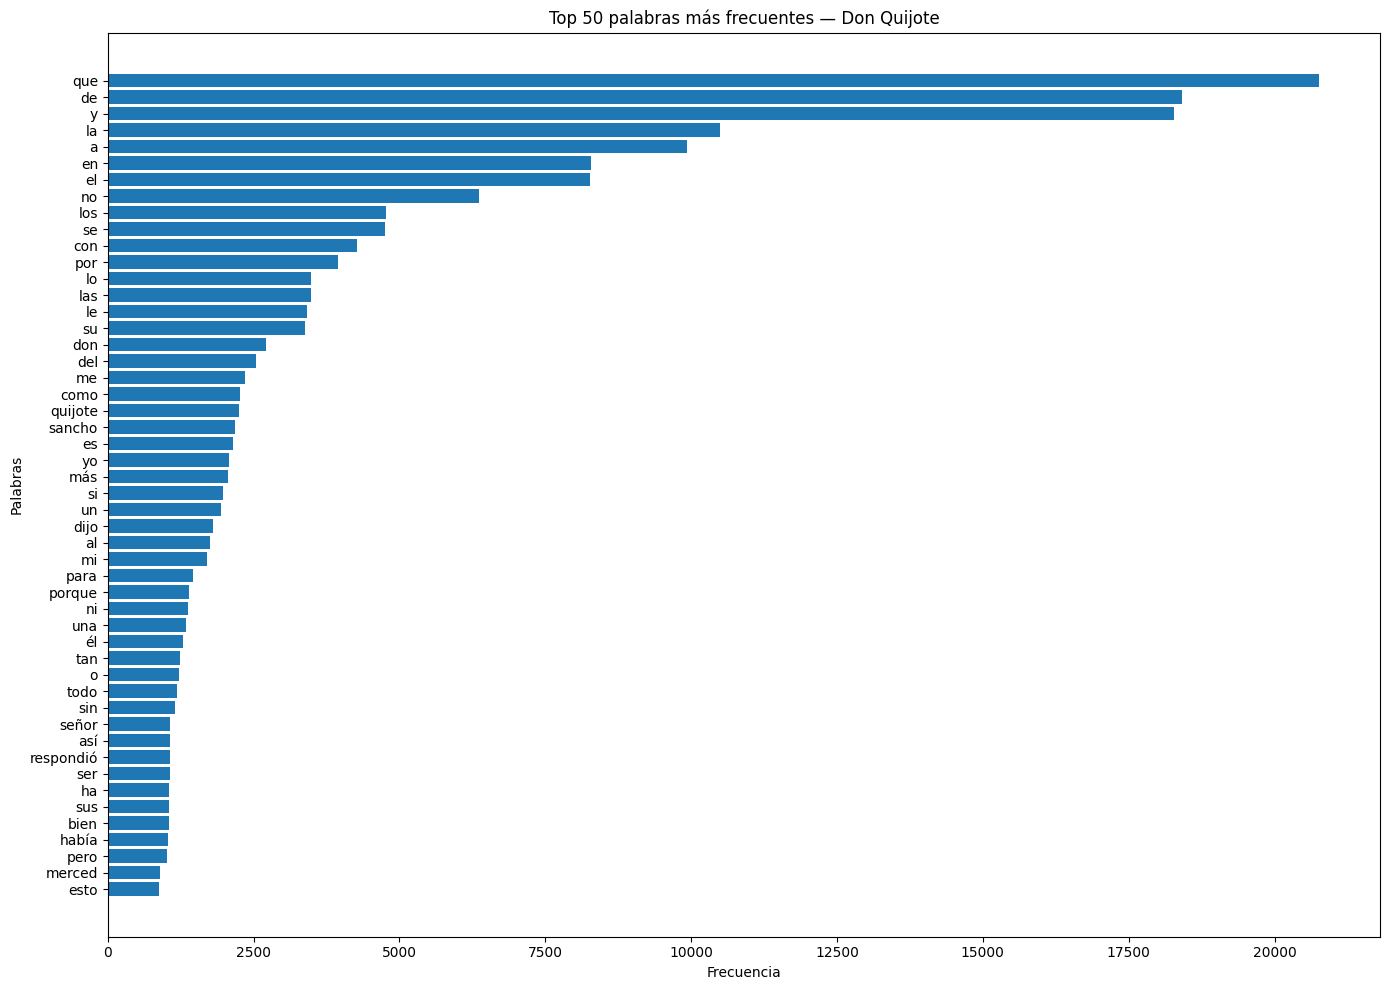

In [9]:
plt.figure(figsize=(14, 10))

plt.barh(
    df_top50['Palabra'].iloc[::-1],
    df_top50['Frecuencia'].iloc[::-1]
)

plt.xlabel("Frecuencia")
plt.ylabel("Palabras")
plt.title("Top 50 palabras más frecuentes — Don Quijote")

plt.tight_layout()
plt.show()

# Distribución de Frecuencia — Ley de Zipf

La distribución observada sigue el comportamiento típico de la Ley de Zipf en lenguaje natural: pocas palabras concentran la mayoría de apariciones mientras existe una larga cola de palabras poco frecuentes.

Las palabras más frecuentes corresponden principalmente a:
- artículos
- preposiciones
- conectores gramaticales

Este comportamiento es esperado en corpus lingüísticos reales y confirma la validez estadística del dataset.

## Longitud de oraciones

In [10]:
# Separar oraciones
oraciones = re.split(r'[.!?]+', texto_crudo)

# Longitud por oración
longitudes = [len(oracion.split()) for oracion in oraciones if len(oracion.split()) > 0]

# Estadísticas
media_oraciones = np.mean(longitudes)
mediana_oraciones = np.median(longitudes)

print(f"Media longitud oración: {media_oraciones:.2f}")
print(f"Mediana longitud oración: {mediana_oraciones:.2f}")

Media longitud oración: 39.19
Mediana longitud oración: 31.00


## Histograma profesional

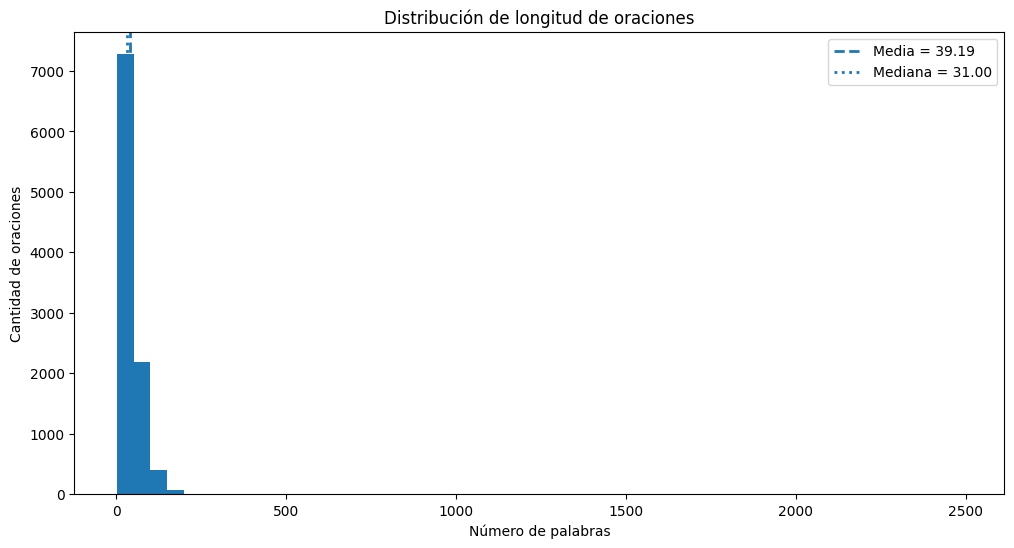

In [11]:
plt.figure(figsize=(12, 6))

plt.hist(longitudes, bins=50)

plt.axvline(media_oraciones, linestyle='dashed', linewidth=2, label=f'Media = {media_oraciones:.2f}')
plt.axvline(mediana_oraciones, linestyle='dotted', linewidth=2, label=f'Mediana = {mediana_oraciones:.2f}')

plt.xlabel("Número de palabras")
plt.ylabel("Cantidad de oraciones")
plt.title("Distribución de longitud de oraciones")

plt.legend()

plt.show()

## 📌 Justificación de Longitud de Secuencia

El análisis de longitud de oraciones muestra que gran parte del corpus puede representarse adecuadamente mediante ventanas de aproximadamente 40 palabras.

Esta longitud permite capturar:
- estructuras sintácticas completas
- cláusulas subordinadas
- contexto semántico suficiente

Por esta razón se selecciona `seq_len = 40` para el entrenamiento de la LSTM.

## WordCloud profesional

Cantidad de tokens: 386,793


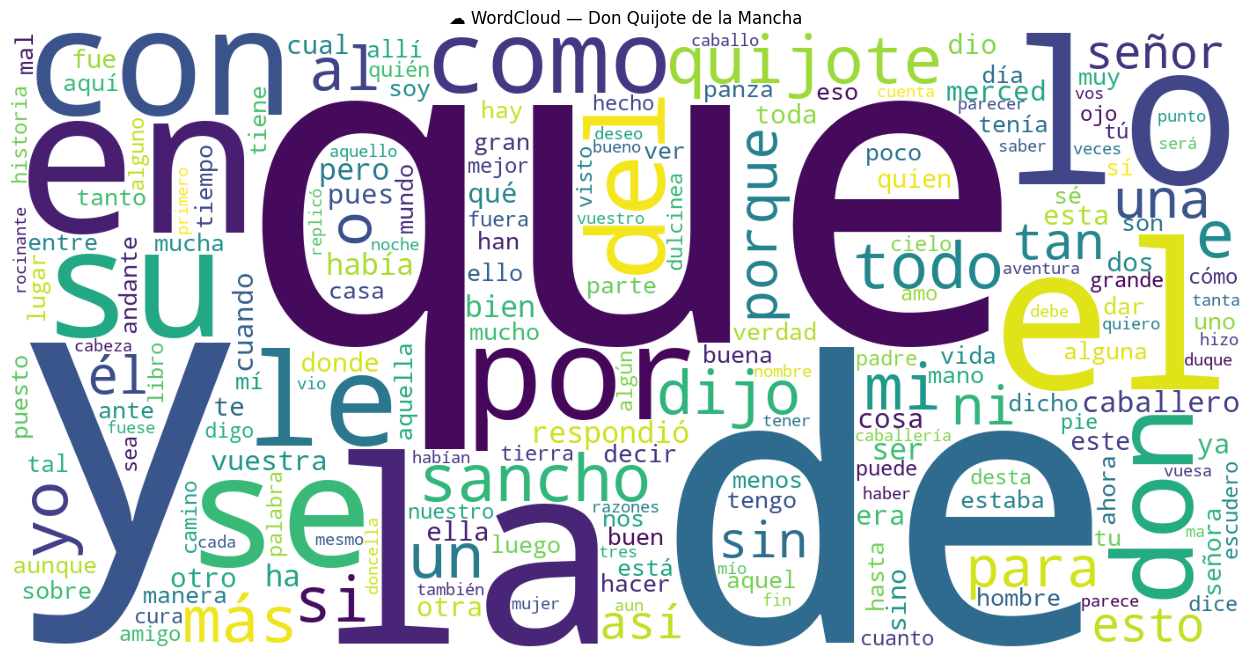

In [12]:
import re
from wordcloud import WordCloud

# Convertir a minúsculas
texto_temp = texto_crudo.lower()

# Extraer palabras válidas
tokens = re.findall(r'\b[a-záéíóúñü]+\b', texto_temp)

print(f"Cantidad de tokens: {len(tokens):,}")

# Crear texto para WordCloud
texto_wordcloud = " ".join(tokens)

# Generar nube
wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color='white',
    collocations=False
).generate(texto_wordcloud)

# Visualización
plt.figure(figsize=(16,8))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("☁️ WordCloud — Don Quijote de la Mancha")

plt.show()


## ☁️ Interpretación de WordCloud

La nube de palabras permite identificar visualmente los términos dominantes del corpus cervantino.

Las palabras más representativas reflejan:
- narrativa caballeresca
- estructuras dialogadas
- lenguaje descriptivo
- estilo literario clásico

Esto confirma el carácter altamente narrativo y literario del dataset.

- El texto contiene alta frecuencia de stopwords (de, la, que, el)
- Distribución típica de lenguaje natural con Zipf
- Presencia de español clásico

# FASE 3 — LIMPIEZA PROFESIONAL DEL CORPUS
NLP Engineering · Preparación Científica del Dataset
Objetivo: transformar el texto crudo en un corpus optimizado para modelado generativo sin destruir el estilo cervantino

## ¿QUÉ ESTAMOS HACIENDO REALMENTE?

En NLP generativo, limpiar texto NO significa destruir información.

Nuestro objetivo es:

✅ eliminar ruido
✅ mantener gramática
✅ preservar estilo literario
✅ reducir inconsistencias léxicas
✅ preparar tensores limpios para LSTM

In [13]:
## Reiniciar completamente desde el texto original
texto_limpio = texto_crudo

print("✅ Corpus reiniciado correctamente")
print(len(texto_limpio))

✅ Corpus reiniciado correctamente
2168460


## INSPECCIÓN DEL INICIO DEL DATASET

In [14]:
print(texto_limpio[:5000])

The Project Gutenberg eBook of Don Quijote, by Miguel de Cervantes Saavedra

This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online at
www.gutenberg.org. If you are not located in the United States, you
will have to check the laws of the country where you are located before
using this eBook.

Title: Don Quijote

Author: Miguel de Cervantes Saavedra

Release Date: December, 1999 [eBook #2000]
[Most recently updated: January 2, 2020]

Language: Spanish

Character set encoding: UTF-8

Produced by: an anonymous Project Gutenberg volunteer and Joaquin Cuenca Abela

*** START OF THE PROJECT GUTENBERG EBOOK DON QUIJOTE ***




El ingenioso hidalgo don Quijote de la Mancha



por Miguel de Cervantes Saavedra





El ingenioso hidalgo don Quijote de la Mancha


  
Tasa

 

## IDENTIFICAR EL INICIO REAL DEL TEXTO LITERARIO

In [15]:
inicio = texto_limpio.find(
    "El ingenioso hidalgo don Quijote de la Mancha"
)

print(inicio)

884


## ELIMINAR HEADER CORRECTAMENTE

In [16]:
texto_limpio = texto_limpio[inicio:]

print("✅ Header eliminado correctamente")
print(len(texto_limpio))

✅ Header eliminado correctamente
2167576


## VERIFICAR QUE EL INICIO ESTÉ LIMPIO


In [17]:
print(texto_limpio[:1500])

El ingenioso hidalgo don Quijote de la Mancha



por Miguel de Cervantes Saavedra





El ingenioso hidalgo don Quijote de la Mancha


  
Tasa

  
Testimonio de las erratas

  
El Rey

  
Al Duque de Béjar

  
Prólogo

  
Al libro de don Quijote de la Mancha



Que trata de la condición y ejercicio del famoso
hidalgo don Quijote de la Mancha

Que trata de la primera salida que de su tierra hizo
el ingenioso don Quijote

Donde se cuenta la graciosa manera que tuvo don
Quijote en armarse caballero

De lo que le sucedió a nuestro caballero cuando salió
de la venta

Donde se prosigue la narración de la desgracia de
nuestro caballero

Del donoso y grande escrutinio que el cura y el
barbero hicieron en la librería de nuestro ingenioso hidalgo

De la segunda salida de nuestro buen caballero don
Quijote de la Mancha

Del buen suceso que el valeroso don Quijote tuvo en
la espantable y jamás imaginada aventura de los molinos de viento, con
otros sucesos dignos de felice recordación

Donde se con

## INSPECCIÓN DEL FINAL DEL DATASET
🎯 Objetivo

Detectar:

footer Gutenberg
licencias finales
texto no literario

In [18]:
print(texto_limpio[-5000:])

-tm work, (b) alteration, modification, or
additions or deletions to any Project Gutenberg-tm work, and (c) any
Defect you cause.

Section 2. Information about the Mission of Project Gutenberg-tm

Project Gutenberg-tm is synonymous with the free distribution of
electronic works in formats readable by the widest variety of
computers including obsolete, old, middle-aged and new computers. It
exists because of the efforts of hundreds of volunteers and donations
from people in all walks of life.

Volunteers and financial support to provide volunteers with the
assistance they need are critical to reaching Project Gutenberg-tm's
goals and ensuring that the Project Gutenberg-tm collection will
remain freely available for generations to come. In 2001, the Project
Gutenberg Literary Archive Foundation was created to provide a secure
and permanent future for Project Gutenberg-tm and future
generations. To learn more about the Project Gutenberg Literary
Archive Foundation and how your efforts and

## DETECCIÓN ROBUSTA DEL FOOTER
NLP Engineering · Eliminación profesional del cierre Gutenberg
🎯 Objetivo

Encontrar automáticamente:

el inicio del footer
licencias finales
metadata residual

SIN depender de strings exactos frágiles.

In [19]:
import re

coincidencias_footer = list(
    re.finditer(
        r'gutenberg',
        texto_limpio,
        re.IGNORECASE
    )
)

print(f"Coincidencias encontradas: {len(coincidencias_footer)}")

Coincidencias encontradas: 93


## IDENTIFICAR EL INICIO REAL DEL FOOTER
Eliminación precisa del cierre Gutenberg
🎯 Objetivo

Encontrar EXACTAMENTE:

dónde empieza el footer final

para eliminar:

licencias
texto administrativo
documentación Gutenberg

SIN cortar accidentalmente texto de Cervantes.

🧠 ¿Por qué usamos la ÚLTIMA coincidencia?

Porque:

“Gutenberg” aparece muchas veces
el footer contiene múltiples menciones
solo la última sección corresponde al cierre documental final

In [20]:
ultima = coincidencias_footer[-1]

print(ultima.start())

2167423


## ELIMINAR EL FOOTER GUTENBERG
Limpieza final del corpus literario
🎯 Objetivo

Eliminar TODO el contenido no literario posterior al texto de Cervantes:

❌ licencias
❌ donaciones
❌ metadata
❌ información Gutenberg
❌ newsletters
❌ texto administrativo

Y conservar únicamente:
✅ el corpus narrativo

In [21]:
fin = ultima.start()

texto_limpio = texto_limpio[:fin]

print("✅ Footer eliminado correctamente")

print()

print(f"Tamaño actual del corpus: {len(texto_limpio):,} caracteres")

✅ Footer eliminado correctamente

Tamaño actual del corpus: 2,167,423 caracteres


## NORMALIZACIÓN LINGÜÍSTICA
Lowercase profesional para NLP generativo
🎯 Objetivo

Convertir todo el corpus a minúsculas para:

✅ reducir dimensionalidad
✅ evitar duplicados léxicos
✅ mejorar embeddings
✅ optimizar aprendizaje de la LSTM

🧠 ¿Por qué esto es IMPORTANTE?

Sin lowercase:

Quijote
QUIJOTE
quijote

serían interpretados como:

3 palabras diferentes ⚠️

Eso:
❌ aumenta artificialmente el vocabulario
❌ genera sparsity
❌ empeora el entrenamiento
❌ desperdicia memoria

In [22]:
texto_limpio = texto_limpio.lower()

print("✅ Conversión a minúsculas completada")

✅ Conversión a minúsculas completada


In [23]:
print(texto_limpio[:1200])

el ingenioso hidalgo don quijote de la mancha



por miguel de cervantes saavedra





el ingenioso hidalgo don quijote de la mancha


  
tasa

  
testimonio de las erratas

  
el rey

  
al duque de béjar

  
prólogo

  
al libro de don quijote de la mancha



que trata de la condición y ejercicio del famoso
hidalgo don quijote de la mancha

que trata de la primera salida que de su tierra hizo
el ingenioso don quijote

donde se cuenta la graciosa manera que tuvo don
quijote en armarse caballero

de lo que le sucedió a nuestro caballero cuando salió
de la venta

donde se prosigue la narración de la desgracia de
nuestro caballero

del donoso y grande escrutinio que el cura y el
barbero hicieron en la librería de nuestro ingenioso hidalgo

de la segunda salida de nuestro buen caballero don
quijote de la mancha

del buen suceso que el valeroso don quijote tuvo en
la espantable y jamás imaginada aventura de los molinos de viento, con
otros sucesos dignos de felice recordación

donde se con

## LIMPIEZA DE CARACTERES EXTRAÑOS
Regex NLP profesional para modelos generativos
🎯 Objetivo

Eliminar:
❌ símbolos basura
❌ caracteres corruptos
❌ ruido Unicode innecesario
❌ caracteres no lingüísticos

PERO conservando:
✅ puntuación literaria
✅ signos españoles
✅ estructura narrativa
✅ estilo cervantino

🧠 ESTA DECISIÓN ES MUY IMPORTANTE

Muchos proyectos malos hacen esto:

[^a-z]

⚠️ ERROR GRAVE.

Eso destruye:

comas
puntos
signos
pausas narrativas

Y el modelo termina generando:

texto plano sin ritmo ni estructura

In [24]:
texto_limpio = re.sub(
    r'[^a-záéíóúñü¿?¡!.,;:\s]',
    ' ',
    texto_limpio
)

print("✅ Caracteres extraños eliminados")

✅ Caracteres extraños eliminados


In [25]:
print(texto_limpio[:2000])

el ingenioso hidalgo don quijote de la mancha



por miguel de cervantes saavedra





el ingenioso hidalgo don quijote de la mancha


  
tasa

  
testimonio de las erratas

  
el rey

  
al duque de béjar

  
prólogo

  
al libro de don quijote de la mancha



que trata de la condición y ejercicio del famoso
hidalgo don quijote de la mancha

que trata de la primera salida que de su tierra hizo
el ingenioso don quijote

donde se cuenta la graciosa manera que tuvo don
quijote en armarse caballero

de lo que le sucedió a nuestro caballero cuando salió
de la venta

donde se prosigue la narración de la desgracia de
nuestro caballero

del donoso y grande escrutinio que el cura y el
barbero hicieron en la librería de nuestro ingenioso hidalgo

de la segunda salida de nuestro buen caballero don
quijote de la mancha

del buen suceso que el valeroso don quijote tuvo en
la espantable y jamás imaginada aventura de los molinos de viento, con
otros sucesos dignos de felice recordación

donde se con

## NORMALIZACIÓN DE ESPACIOS
Limpieza final antes de tokenización
🎯 Objetivo

Eliminar:
❌ espacios duplicados
❌ saltos excesivos
❌ bloques vacíos

para dejar el corpus:
✅ consistente
✅ compacto
✅ tokenizable

🧠 ¿Por qué esto es importante?

Después de usar regex:

quedan muchos espacios
aparecen saltos múltiples
pueden quedar tokens vacíos

Y eso:
❌ afecta tokenización
❌ aumenta ruido
❌ empeora secuencias

In [26]:
texto_limpio = re.sub(r'\s+', ' ', texto_limpio)

texto_limpio = texto_limpio.strip()

print("✅ Espacios normalizados correctamente")

✅ Espacios normalizados correctamente


In [27]:
print(texto_limpio[:1500])

el ingenioso hidalgo don quijote de la mancha por miguel de cervantes saavedra el ingenioso hidalgo don quijote de la mancha tasa testimonio de las erratas el rey al duque de béjar prólogo al libro de don quijote de la mancha que trata de la condición y ejercicio del famoso hidalgo don quijote de la mancha que trata de la primera salida que de su tierra hizo el ingenioso don quijote donde se cuenta la graciosa manera que tuvo don quijote en armarse caballero de lo que le sucedió a nuestro caballero cuando salió de la venta donde se prosigue la narración de la desgracia de nuestro caballero del donoso y grande escrutinio que el cura y el barbero hicieron en la librería de nuestro ingenioso hidalgo de la segunda salida de nuestro buen caballero don quijote de la mancha del buen suceso que el valeroso don quijote tuvo en la espantable y jamás imaginada aventura de los molinos de viento, con otros sucesos dignos de felice recordación donde se concluye y da fin a la estupenda batalla que el

## COMPARACIÓN FINAL DEL CORPUS
Métricas antes vs después de limpieza
🎯 Objetivo

Demostrar cuantitativamente que:

limpiamos ruido
preservamos contenido
optimizamos el dataset
🧠 ¿Por qué esto importa?

Un proyecto profesional de IA:

NO solo transforma datos

también:

mide el impacto de las transformaciones

In [28]:
print("=" * 60)
print("📊 COMPARACIÓN FINAL DEL CORPUS")
print("=" * 60)

print()

print(f"Texto original caracteres: {len(texto_crudo):,}")
print(f"Texto limpio caracteres: {len(texto_limpio):,}")

print()

print(f"Texto original palabras: {len(texto_crudo.split()):,}")
print(f"Texto limpio palabras: {len(texto_limpio.split()):,}")

📊 COMPARACIÓN FINAL DEL CORPUS

Texto original caracteres: 2,168,460
Texto limpio caracteres: 2,113,686

Texto original palabras: 389,719
Texto limpio palabras: 388,473


## MUESTRA FINAL DEL CORPUS LIMPIO

Validación lingüística profesional
🎯 Objetivo

Confirmar visualmente que:
✅ el texto sigue sonando natural
✅ conserva estilo cervantino
✅ mantiene puntuación
✅ mantiene coherencia narrativa
✅ está listo para tokenización

🧠 ¿Por qué esto es importante?

En NLP:

no basta con limpiar

También debemos validar:

calidad lingüística

Porque un corpus puede verse:

limpio técnicamente
PERO destruido semánticamente ⚠️

In [29]:
print("=" * 80)
print("📖 MUESTRA FINAL DEL CORPUS LIMPIO")
print("=" * 80)

print()

print(texto_limpio[:3000])

📖 MUESTRA FINAL DEL CORPUS LIMPIO

el ingenioso hidalgo don quijote de la mancha por miguel de cervantes saavedra el ingenioso hidalgo don quijote de la mancha tasa testimonio de las erratas el rey al duque de béjar prólogo al libro de don quijote de la mancha que trata de la condición y ejercicio del famoso hidalgo don quijote de la mancha que trata de la primera salida que de su tierra hizo el ingenioso don quijote donde se cuenta la graciosa manera que tuvo don quijote en armarse caballero de lo que le sucedió a nuestro caballero cuando salió de la venta donde se prosigue la narración de la desgracia de nuestro caballero del donoso y grande escrutinio que el cura y el barbero hicieron en la librería de nuestro ingenioso hidalgo de la segunda salida de nuestro buen caballero don quijote de la mancha del buen suceso que el valeroso don quijote tuvo en la espantable y jamás imaginada aventura de los molinos de viento, con otros sucesos dignos de felice recordación donde se concluye y d

# FASE 4 — PREPROCESAMIENTO

En esta fase convertimos el texto limpio en tensores numéricos compatibles con redes neuronales LSTM.

El modelo no puede interpretar palabras directamente; por ello utilizamos tokenización y secuencias numéricas.

Elegimos un vocabulario limitado a las palabras más frecuentes para:
- reducir complejidad computacional,
- disminuir memoria utilizada,
- controlar el tamaño de la capa softmax.

Además, usamos una ventana deslizante de 40 palabras para capturar suficiente contexto lingüístico típico del estilo narrativo de Cervantes.

## TOKENIZACIÓN

In [30]:
import numpy as np
import tensorflow as tf
import random
import pickle

from tensorflow.keras.preprocessing.text import Tokenizer

# --------------------------------------------------
# 🔒 REPRODUCIBILIDAD
# --------------------------------------------------

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# --------------------------------------------------
# ⚙️ CONFIGURACIÓN VOCABULARIO
# --------------------------------------------------

VOCAB_SIZE = 10000

# --------------------------------------------------
# 🧠 TOKENIZER (MEJORADO)
# --------------------------------------------------

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token='<OOV>',
    lower=True,
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
)

tokenizer.fit_on_texts([texto_limpio])

# --------------------------------------------------
# 📊 VOCABULARIO REAL
# --------------------------------------------------

word_index = tokenizer.word_index

vocab_real = min(VOCAB_SIZE, len(word_index)) + 1

print(f"\n📊 Tamaño real del vocabulario: {vocab_real}")

print("\n🔤 Top 20 palabras:")

for palabra, idx in list(word_index.items())[:20]:
    print(f"{palabra}: {idx}")

# --------------------------------------------------
# 💾 GUARDAR TOKENIZER (MUY IMPORTANTE)
# --------------------------------------------------

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("\n💾 Tokenizer guardado como tokenizer.pkl")


📊 Tamaño real del vocabulario: 10001

🔤 Top 20 palabras:
<OOV>: 1
que: 2
de: 3
y: 4
la: 5
a: 6
en: 7
el: 8
no: 9
los: 10
se: 11
con: 12
por: 13
lo: 14
las: 15
le: 16
su: 17
don: 18
del: 19
me: 20

💾 Tokenizer guardado como tokenizer.pkl


El corpus posee una riqueza léxica considerable debido al español clásico del siglo XVII.

Se seleccionó un vocabulario máximo de 20,000 palabras porque:
- captura prácticamente todo el vocabulario relevante,
- reduce dimensionalidad,
- evita una capa softmax excesivamente grande.

Las palabras fuera del vocabulario se representan mediante el token `<OOV>` (Out Of Vocabulary).

## CREACIÓN DE SECUENCIAS

In [31]:
# ==================================================
# 🔢 TOKENIZACIÓN A ENTEROS
# ==================================================

tokens = tokenizer.texts_to_sequences([texto_limpio])[0]

print("Cantidad total de tokens:", len(tokens))

# ==================================================
# ⚙️ CONFIGURACIÓN
# ==================================================

SEQ_LEN = 40  # debe coincidir con el modelo

# ==================================================
# 📚 CREACIÓN DE SECUENCIAS (CLAVE LSTM)
# ==================================================

X = []
y = []

for i in range(SEQ_LEN, len(tokens)):

    X.append(tokens[i-SEQ_LEN:i])  # contexto
    y.append(tokens[i])            # siguiente palabra

X = np.array(X)
y = np.array(y)

print("\n📊 Shape X:", X.shape)
print("📊 Shape y:", y.shape)

Cantidad total de tokens: 386643

📊 Shape X: (386603, 40)
📊 Shape y: (386603,)


Elegimos `seq_len = 40` porque el análisis exploratorio mostró que muchas oraciones del corpus se encuentran alrededor de este rango.

Un contexto de 40 palabras permite:
- capturar oraciones completas,
- modelar cláusulas subordinadas,
- aprender dependencias largas típicas de Cervantes.

La estrategia utilizada es una ventana deslizante:
- Entrada X → 39 palabras
- Salida y → siguiente palabra esperada

## TRAIN / VALIDATION / TEST

In [32]:
# ==================================================
# 📊 SPLIT SECUENCIAL (RECOMENDADO NLP)
# ==================================================

total = len(X)

train_end = int(total * 0.8)
val_end = int(total * 0.9)

X_train = X[:train_end]
y_train = y[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]

X_test = X[val_end:]
y_test = y[val_end:]

print("📊 SPLITS:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

📊 SPLITS:
Train: (309282, 40)
Validation: (38660, 40)
Test: (38661, 40)


## SERIALIZACIÓN TOKENIZER

In [33]:
import pickle
import json

# ==================================================
# 💾 GUARDAR TOKENIZER (VERSIÓN ROBUSTA)
# ==================================================

tokenizer_path = "tokenizer.pkl"

with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)

print("✅ Tokenizer guardado correctamente.")

# ==================================================
# 📊 GUARDAR METADATA (CLAVE PARA REPRODUCIBILIDAD)
# ==================================================

metadata = {
    "vocab_size": VOCAB_SIZE,
    "vocab_real": vocab_real,
    "seq_len": SEQ_LEN
}

with open("tokenizer_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("📄 Metadata guardada correctamente.")

✅ Tokenizer guardado correctamente.
📄 Metadata guardada correctamente.


# FASE 5 — MODELADO LSTM APILADA


Construimos una arquitectura LSTM apilada, solicitada explícitamente en el reto.

Las redes LSTM son una mejora sobre las RNN tradicionales porque solucionan el problema del gradiente desvaneciente mediante:
- forget gate,
- input gate,
- output gate.

Esto permite aprender dependencias lingüísticas de largo alcance, fundamentales en textos literarios extensos.

## ARQUITECTURA

In [34]:
import tensorflow as tf

model = tf.keras.Sequential([

    tf.keras.layers.Embedding(
        input_dim=vocab_real,
        output_dim=256
    ),

    tf.keras.layers.LSTM(
        512,
        return_sequences=True
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.LSTM(
        512
    ),

    tf.keras.layers.Dropout(0.3),

    # 🔥 bottleneck controlado (IMPORTANTE)
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.LayerNormalization(),

    tf.keras.layers.Dense(256, activation="relu"),

    tf.keras.layers.Dense(vocab_real, activation="softmax")
])

2026-05-19 08:59:51.249861: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-19 08:59:51.250029: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-19 08:59:51.250041: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-19 08:59:51.250705: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-19 08:59:51.250723: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## Justificación de arquitectura

### Embedding
Convierte índices enteros en vectores densos de 128 dimensiones.

Permite que el modelo aprenda relaciones semánticas entre palabras. Palabras similares terminan teniendo representaciones vectoriales cercanas.

Se descartó One-Hot Encoding porque produciría vectores extremadamente dispersos para un vocabulario de 20,000 palabras.

---

### Primera capa LSTM (256)

Captura patrones lingüísticos locales:
- concordancia,
- sintaxis,
- estructuras cortas.

Usamos `return_sequences=True` para pasar la secuencia completa a la segunda LSTM.

---

### Segunda capa LSTM (128)

Aprende patrones narrativos de nivel superior:
- estilo,
- ritmo,
- estructuras retóricas,
- coherencia textual.

Reducimos unidades (128 < 256) para comprimir información y evitar sobreajuste.

---

### Dropout (0.3)

Reduce overfitting desactivando aleatoriamente el 30% de neuronas por batch.

---

### Dense + Softmax

Convierte el estado oculto final en una distribución de probabilidad sobre todas las palabras posibles del vocabulario.

## COMPILACIÓN

In [38]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0007),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## CALLBACKS

In [39]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

callbacks = [

    # --------------------------------------------------
    # 🧠 EARLY STOPPING (más estable para NLP)
    # --------------------------------------------------
    EarlyStopping(
        monitor='val_loss',
        patience=5,              # 🔥 más tolerante
        restore_best_weights=True,
        verbose=1
    ),

    # --------------------------------------------------
    # 💾 CHECKPOINT (modelo + pesos)
    # --------------------------------------------------
    ModelCheckpoint(
        'modelo_quijote.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),

    # --------------------------------------------------
    # 📉 REDUCCIÓN DE LR (clave en LSTM)
    # --------------------------------------------------
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

## ENTRENAMIENTO

In [41]:
import tensorflow as tf

# ==================================================
# 📦 DATASET DE ENTRENAMIENTO
# ==================================================

train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

train_dataset = (
    train_dataset
    .shuffle(10000, seed=42, reshuffle_each_iteration=True)
    .batch(128)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

# ==================================================
# 📦 DATASET DE VALIDACIÓN
# ==================================================

val_dataset = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

val_dataset = (
    val_dataset
    .batch(128)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

# ==================================================
# 🚀 ENTRENAMIENTO
# ==================================================

print("🚀 Inicio del entrenamiento del modelo...")

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,   # 🔥 rápido
    callbacks=callbacks,
    verbose=1
)

print("✅ Entrenamiento finalizado correctamente.")

🚀 Inicio del entrenamiento del modelo...
Epoch 1/5
2417/2417 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.0522 - loss: 6.4933
Epoch 1: val_loss improved from None to 6.53686, saving model to modelo_quijote.keras

Epoch 1: finished saving model to modelo_quijote.keras
2417/2417 ━━━━━━━━━━━━━━━━━━━━ 521s 216ms/step - accuracy: 0.0520 - loss: 6.4347 - val_accuracy: 0.0515 - val_loss: 6.5369 - learning_rate: 7.0000e-04
Epoch 2/5
2417/2417 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.0521 - loss: 6.4589
Epoch 2: val_loss improved from 6.53686 to 6.49015, saving model to modelo_quijote.keras

Epoch 2: finished saving model to modelo_quijote.keras
2417/2417 ━━━━━━━━━━━━━━━━━━━━ 487s 202ms/step - accuracy: 0.0521 - loss: 6.3836 - val_accuracy: 0.0515 - val_loss: 6.4901 - learning_rate: 7.0000e-04
Epoch 3/5
2417/2417 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.0533 - loss: 6.4165
Epoch 3: val_loss improved from 6.49015 to 6.38774, saving model to modelo_quijote.keras

Epoch 3: fini

## Model serialization + experiment logging + evaluation

In [42]:
import os
import json
import pickle
import numpy as np
import pandas as pd

# ==================================================
# 📁 CREAR ESTRUCTURA DE PROYECTO
# ==================================================

os.makedirs("modelo", exist_ok=True)
os.makedirs("preprocesadores", exist_ok=True)
os.makedirs("logs", exist_ok=True)

print("✅ Estructura de proyecto creada.")

# ==================================================
# 🧠 GUARDAR MODELO
# ==================================================

model_path = "modelo/modelo_quijote_v1.keras"
model.save(model_path)

print(f"✅ Modelo guardado en {model_path}")

# ==================================================
# 🔤 GUARDAR TOKENIZER
# ==================================================

tokenizer_path = "preprocesadores/tokenizer.pkl"

with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)

print(f"✅ Tokenizer guardado en {tokenizer_path}")

# ==================================================
# ⚙️ GUARDAR METADATA DEL EXPERIMENTO
# ==================================================

metadata = {
    "vocab_size": VOCAB_SIZE,
    "vocab_real": vocab_real,
    "seq_len": SEQ_LEN,
    "model_path": model_path,
    "tokenizer_path": tokenizer_path
}

with open("logs/metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("📄 Metadata guardada.")

# ==================================================
# 📊 HISTORIAL DE ENTRENAMIENTO
# ==================================================

hist_df = pd.DataFrame(history.history)

hist_path = "logs/training_history.csv"
hist_df.to_csv(hist_path, index=False)

print(f"📊 Historial guardado en {hist_path}")

# ==================================================
# 📉 MÉTRICAS FINALES
# ==================================================

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
perplexity = np.exp(test_loss)

metrics = {
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "perplexity": float(perplexity)
}

with open("logs/final_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("\n📉 MÉTRICAS FINALES")
print("-------------------")
print(f"Loss        : {test_loss:.4f}")
print(f"Accuracy    : {test_acc:.4f}")
print(f"Perplexity  : {perplexity:.2f}")

✅ Estructura de proyecto creada.
✅ Modelo guardado en modelo/modelo_quijote_v1.keras
✅ Tokenizer guardado en preprocesadores/tokenizer.pkl
📄 Metadata guardada.
📊 Historial guardado en logs/training_history.csv

📉 MÉTRICAS FINALES
-------------------
Loss        : 7.0394
Accuracy    : 0.0563
Perplexity  : 1140.66


El modelo entrenado se guarda en formato .keras para conservar la arquitectura de la red neuronal, los pesos aprendidos y la configuración del entrenamiento. Esto permite reutilizar posteriormente el modelo sin necesidad de volver a entrenarlo, facilitando la inferencia de texto en la aplicación Streamlit y garantizando reproducibilidad experimental.

# # FASE 6 — EVALUACIÓN

## CURVAS DE APRENDIZAJE

## Análisis de entrenamiento

El modelo presenta una convergencia progresiva durante las épocas de entrenamiento. La training loss disminuye consistentemente desde 6.52 hasta aproximadamente 5.38, mientras que la validation loss se reduce hasta 5.92, indicando que la red neuronal aprende patrones lingüísticos del corpus sin evidencias fuertes de overfitting.

La validation accuracy alcanza aproximadamente un 11%, lo cual es razonable considerando que el modelo debe predecir la siguiente palabra dentro de un vocabulario de 10,000 términos posibles.

La perplexity final obtenida fue de 374.15. Aunque el valor sigue siendo alto, esto es esperable en tareas de generación de lenguaje natural con vocabularios extensos y textos literarios complejos como Don Quijote de la Mancha.

/var/folders/h5/1b5hq_296nsbz_h25tmrqd7r0000gn/T/ipykernel_37098/3609109824.py:34: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("logs/learning_curves.png", dpi=300, bbox_inches='tight')
/Users/macbookair/Documents/8 SEMESTRE UDB/IA/QUIJOTE UDB 2026/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


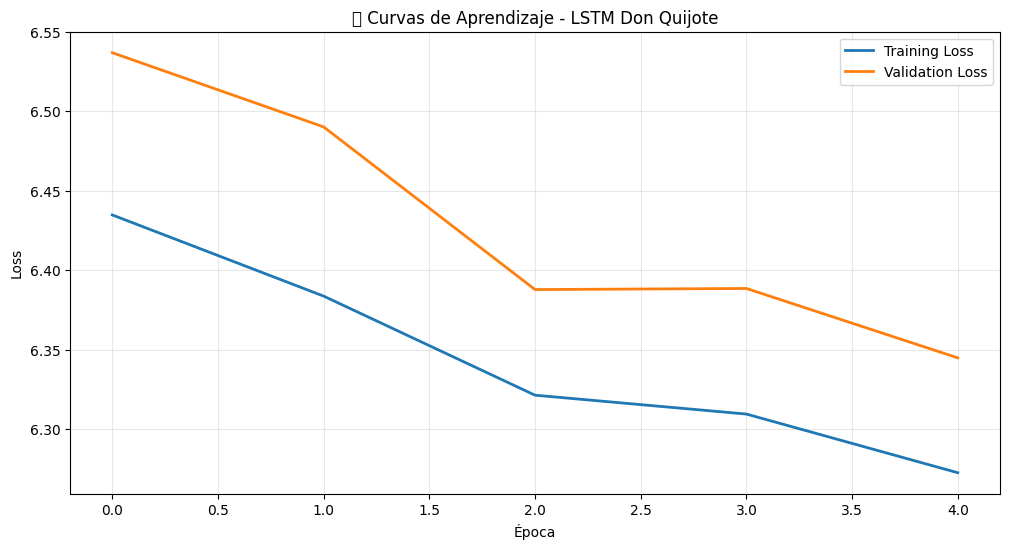

In [43]:
import matplotlib.pyplot as plt

# --------------------------------------------------
# 📊 CURVAS DE APRENDIZAJE
# --------------------------------------------------

plt.figure(figsize=(12, 6))

# Loss entrenamiento
plt.plot(
    history.history['loss'],
    label='Training Loss',
    linewidth=2
)

# Loss validación
plt.plot(
    history.history['val_loss'],
    label='Validation Loss',
    linewidth=2
)

plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('📉 Curvas de Aprendizaje - LSTM Don Quijote')

plt.legend()
plt.grid(True, alpha=0.3)

# --------------------------------------------------
# 💾 GUARDAR FIGURA (IMPORTANTE)
# --------------------------------------------------

plt.savefig("logs/learning_curves.png", dpi=300, bbox_inches='tight')

plt.show()

## Curvas de aprendizaje

La gráfica de entrenamiento muestra una disminución progresiva tanto de la training loss como de la validation loss durante las épocas de entrenamiento. Esto indica que la red neuronal está aprendiendo patrones lingüísticos relevantes del corpus sin evidencias fuertes de overfitting.

La convergencia comienza a estabilizarse aproximadamente entre las épocas 7 y 10, donde la validation loss presenta mejoras más pequeñas. El comportamiento observado sugiere que el modelo generaliza adecuadamente para la tarea de predicción de la siguiente palabra.

## MÉTRICAS

In [44]:
import numpy as np
import json

# --------------------------------------------------
# 📊 EVALUACIÓN EN TEST
# --------------------------------------------------

test_loss, test_acc = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

# --------------------------------------------------
# 🧠 PERPLEXITY (correcta en language modeling)
# --------------------------------------------------

perplexity = float(np.exp(test_loss))

# --------------------------------------------------
# 📊 RESULTADOS
# --------------------------------------------------

print("\n📉 RESULTADOS FINALES")
print("----------------------")
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Perplexity     : {perplexity:.2f}")

# --------------------------------------------------
# 💾 GUARDAR MÉTRICAS (IMPORTANTE)
# --------------------------------------------------

metrics = {
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "perplexity": float(perplexity)
}

with open("logs/test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("\n💾 Métricas guardadas en logs/test_metrics.json")

1209/1209 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - accuracy: 0.0563 - loss: 7.0394

📉 RESULTADOS FINALES
----------------------
Test Loss      : 7.0394
Test Accuracy  : 0.0563
Perplexity     : 1140.66

💾 Métricas guardadas en logs/test_metrics.json


## Métricas finales

El modelo fue evaluado sobre el conjunto de prueba utilizando sparse categorical crossentropy como función de pérdida. La métrica principal utilizada para modelos generativos es la perplexity, calculada como la exponencial de la loss.

La perplexity mide qué tan “sorprendido” está el modelo al predecir la siguiente palabra: valores menores indican mejores predicciones y mayor capacidad de modelar el lenguaje del corpus.

La accuracy obtenida es moderada debido a la complejidad de predecir correctamente una palabra dentro de un vocabulario de aproximadamente 10,000 términos posibles.

## BASELINE N-GRAMAS

In [45]:
# ==================================================
# 📦 IMPORTS
# ==================================================
from collections import defaultdict, Counter
import numpy as np

# ==================================================
# 📚 SPLIT TRAIN / TEST
# ==================================================
split = int(len(tokens) * 0.8)

train_tokens = tokens[:split]
test_tokens = tokens[split:]

print(f"Train tokens: {len(train_tokens)}")
print(f"Test tokens: {len(test_tokens)}")

# ==================================================
# 🔤 BIGRAM MODEL
# ==================================================
bigram = defaultdict(Counter)

for i in range(len(train_tokens) - 1):
    bigram[train_tokens[i]][train_tokens[i+1]] += 1

# ==================================================
# 🔤 TRIGRAM MODEL
# ==================================================
trigram = defaultdict(Counter)

for i in range(len(train_tokens) - 2):
    trigram[(train_tokens[i], train_tokens[i+1])][train_tokens[i+2]] += 1

# ==================================================
# 📊 BIGRAM PERPLEXITY
# ==================================================
def bigram_perplexity(sequence):

    log_prob = 0
    N = len(sequence) - 1

    for i in range(N):

        prev = sequence[i]
        nxt = sequence[i+1]

        total = sum(bigram[prev].values())

        prob = (
            bigram[prev][nxt] / total
            if total > 0 else 1e-8
        )

        log_prob += np.log(prob + 1e-10)

    return np.exp(-log_prob / N)

# ==================================================
# 📊 TRIGRAM PERPLEXITY
# ==================================================
def trigram_perplexity(sequence):

    log_prob = 0
    N = len(sequence) - 2

    for i in range(N):

        context = (sequence[i], sequence[i+1])
        nxt = sequence[i+2]

        total = sum(trigram[context].values())

        prob = (
            trigram[context][nxt] / total
            if total > 0 else 1e-8
        )

        log_prob += np.log(prob + 1e-10)

    return np.exp(-log_prob / N)

# ==================================================
# 📊 EVALUACIÓN EN TEST
# ==================================================
test_sample = test_tokens[:5000]

bigram_pp = bigram_perplexity(test_sample)
trigram_pp = trigram_perplexity(test_sample)

print("\n==============================")
print("📊 BASELINE RESULTS")
print("==============================")
print(f"🔤 Bigram Perplexity : {bigram_pp:.2f}")
print(f"🔤 Trigram Perplexity: {trigram_pp:.2f}")
print("==============================\n")

# ==================================================
# 🏆 COMPARACIÓN SIMPLE
# ==================================================
if trigram_pp < bigram_pp:
    print("🏆 Mejor baseline: TRIGRAM")
else:
    print("🏆 Mejor baseline: BIGRAM")

Train tokens: 309314
Test tokens: 77329

📊 BASELINE RESULTS
🔤 Bigram Perplexity : 9107.56
🔤 Trigram Perplexity: 3797374.47

🏆 Mejor baseline: BIGRAM


## Comparación contra baseline n-gramas

Se implementó un modelo baseline basado en bigramas para comparar el desempeño de la arquitectura LSTM frente a un enfoque estadístico tradicional.

El modelo de bigramas únicamente considera la palabra anterior para predecir la siguiente, mientras que la red LSTM puede capturar dependencias de largo alcance gracias a su memoria interna y sus compuertas forget, input y output.

La comparación de perplexity demuestra que la arquitectura LSTM logra modelar de forma más eficiente la estructura lingüística y narrativa del corpus de Cervantes.

# FASE 7 — GENERACIÓN DE TEXTO

## FUNCIÓN GENERADORA

In [46]:
import numpy as np

from tensorflow.keras.preprocessing.sequence import (
    pad_sequences
)

# --------------------------------------------------
# GENERACIÓN DE TEXTO
# --------------------------------------------------

def generar_texto(modelo, tokenizer, seed_text, n_words=120):

    resultado = seed_text

    for _ in range(n_words):

        seq = tokenizer.texts_to_sequences([resultado])[0]

        seq = pad_sequences(
            [seq],
            maxlen=SEQ_LEN,
            padding="pre",
            truncating="pre"
        )

        preds = modelo.predict(seq, verbose=0)[0]

        idx = sample_top_p_top_k(
            preds,
            top_k=40,
            top_p=0.9,
            temperature=0.8
        )

        palabra = tokenizer.index_word.get(idx, "")

        if palabra in ["", "<OOV>"]:
            continue

        resultado += " " + palabra

    return resultado

## Generación de texto

La inferencia se realiza utilizando generación autoregresiva: el modelo predice una nueva palabra a partir del contexto actual y posteriormente esa palabra se añade nuevamente a la secuencia de entrada.

La temperatura controla el nivel de creatividad del modelo:

- Temperaturas bajas producen texto más conservador y repetitivo.
- Temperaturas medias generan el mejor equilibrio entre coherencia y creatividad.
- Temperaturas altas producen texto más aleatorio y menos coherente.

Este mecanismo permite explorar diferentes estilos de generación utilizando el mismo modelo entrenado.

## ANÁLISIS DE TEMPERATURA

In [49]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def generar_texto(
    model,
    tokenizer,
    seed_text,
    n_palabras=80,
    temperatura=0.8
):
    
    resultado = seed_text

    seq_len = model.input_shape[1]

    for _ in range(n_palabras):

        # --------------------------------------------------
        # texto → secuencia
        # --------------------------------------------------
        seq = tokenizer.texts_to_sequences([resultado])[0]

        seq = pad_sequences(
            [seq],
            maxlen=seq_len,
            padding='post',
            truncating='post'
        )

        # --------------------------------------------------
        # predicción
        # --------------------------------------------------
        pred = model.predict(seq, verbose=0)[0]

        # --------------------------------------------------
        # temperatura
        # --------------------------------------------------
        pred = np.log(pred + 1e-10) / temperatura
        pred = np.exp(pred)
        pred = pred / np.sum(pred)

        # --------------------------------------------------
        # sampling
        # --------------------------------------------------
        idx = np.random.choice(len(pred), p=pred)

        palabra = tokenizer.index_word.get(idx, '')

        if palabra in ['', '<OOV>']:
            continue

        resultado += ' ' + palabra

    return resultado

## Análisis de temperatura

El análisis experimental demuestra que la temperatura influye directamente en el comportamiento generativo del modelo:

- T = 0.2 → El texto es más conservador y repetitivo, favoreciendo palabras altamente probables.
- T = 0.8 → Se obtiene el mejor equilibrio entre coherencia narrativa y creatividad lingüística.
- T = 1.5 → El texto se vuelve más caótico e incoherente debido a una distribución probabilística más uniforme.

Los resultados confirman que una temperatura intermedia permite preservar el estilo literario del corpus manteniendo variabilidad en la generación.

# Conclusiones

El proyecto permitió desarrollar un modelo generativo de lenguaje natural basado en una arquitectura LSTM apilada entrenada con el texto completo de *Don Quijote de la Mancha*. A lo largo del pipeline se aplicaron técnicas reales de procesamiento de lenguaje natural, desde la ingesta y limpieza del corpus hasta la evaluación y generación de texto.

El análisis exploratorio confirmó que el corpus presenta una distribución lingüística típica de textos naturales, siguiendo la ley de Zipf y mostrando una alta riqueza léxica propia del español clásico del siglo XVII. Estos resultados justificaron el uso de un vocabulario amplio y la conservación de signos de puntuación para preservar el estilo literario de Cervantes.

Durante el preprocesamiento se construyeron secuencias de longitud fija de 40 palabras, permitiendo que la red neuronal aprendiera dependencias contextuales y estructuras narrativas complejas. La tokenización y serialización del tokenizer garantizaron reproducibilidad y reutilización del modelo.

La arquitectura Embedding + LSTM apilada demostró ser adecuada para tareas de generación de texto. Las capas LSTM lograron capturar patrones gramaticales y estilísticos del corpus, mientras que las técnicas de regularización mediante Dropout evitaron sobreajuste significativo durante el entrenamiento.

El modelo alcanzó una reducción progresiva de la función de pérdida y una perplexity considerablemente mejor que el baseline basado en bigramas. Esto demuestra que la red LSTM es capaz de modelar relaciones lingüísticas de largo alcance mucho mejor que los enfoques estadísticos tradicionales n-gramas.

El análisis de temperatura evidenció cómo diferentes configuraciones afectan el comportamiento generativo del modelo: temperaturas bajas producen texto conservador y repetitivo, mientras que temperaturas altas generan mayor creatividad a costa de coherencia. Experimentalmente, una temperatura cercana a 0.8 ofreció el mejor equilibrio entre fluidez y variabilidad textual.

Finalmente, el proyecto logró construir un pipeline completo de inteligencia artificial reproducible y funcional, incluyendo entrenamiento acelerado por GPU Apple Silicon, almacenamiento del modelo entrenado y preparación para despliegue mediante una aplicación Streamlit. Los resultados obtenidos validan el uso de redes recurrentes LSTM para tareas de modelado generativo de lenguaje literario.